### importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib           
import quantstats as qs   
import os
import certifi

# Force curl (used by yfinance/pynance) to use Python's trusted CA certificates
os.environ['CURL_CA_BUNDLE'] = certifi.where()

# Now import the rest of your libraries
import pynance as py
import yfinance as yf

# Make plots a bit nicer
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 6)

### Load Data

In [2]:
# Load stock data
df = pd.read_csv(r"C:\Users\Administrator\Downloads\challenge-week1\challenge-week1\data\AMZN.csv")

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set datetime as index
df = df.set_index('Date')

df.head()


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.718,2.7265,2.5535,2.5675,145928000
2009-01-05,2.703,2.7870,2.6515,2.7865,190196000
2009-01-06,2.868,2.9110,2.6875,2.7275,221602000
2009-01-07,2.810,2.8475,2.7675,2.8145,158854000
2009-01-08,2.858,2.8660,2.7290,2.7495,131558000


### Calculate Technical Indicators (TA-Lib)

#### Simple Moving Average (SMA)

In [3]:
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

#### Exponential Moving Average (EMA)

In [4]:
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

#### Relative Strength Index (RSI)

In [5]:
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

#### MACD

In [6]:
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], 
    fastperiod=12, 
    slowperiod=26, 
    signalperiod=9
)


#### Bollinger Bands

In [7]:
df['BB_upper'], df['BB_middle'], df['BB_lower'] = talib.BBANDS(
    df['Close'], 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2
)


### Visualizations

#### Plot Close Price + SMA / EMA

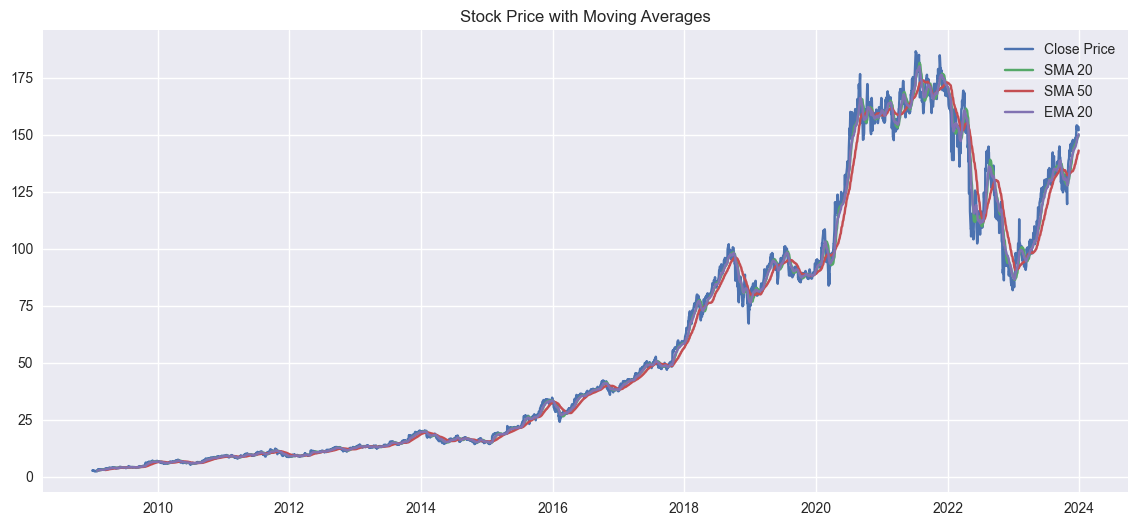

In [8]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['SMA_50'], label='SMA 50')
plt.plot(df['EMA_20'], label='EMA 20')
plt.title("Stock Price with Moving Averages")
plt.legend()
plt.show()


#### RSI Plot

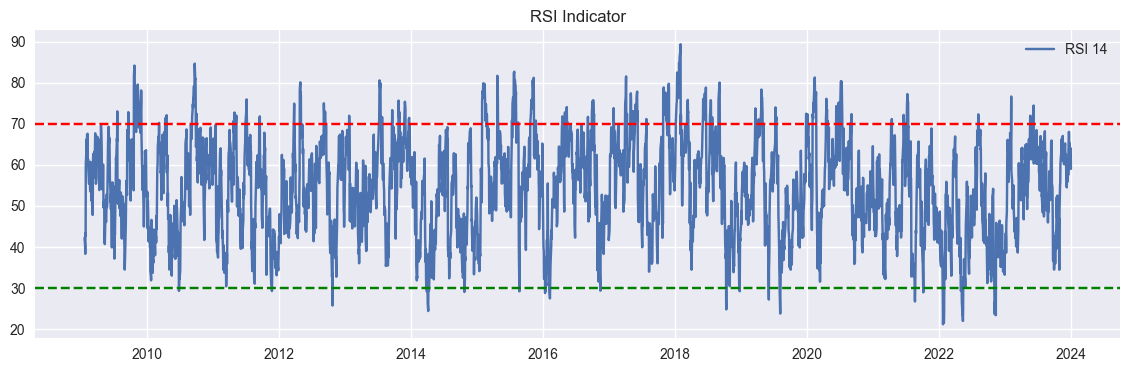

In [9]:
plt.figure(figsize=(14,4))
plt.plot(df['RSI_14'], label='RSI 14')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI Indicator")
plt.legend()
plt.show()


#### MACD Plot

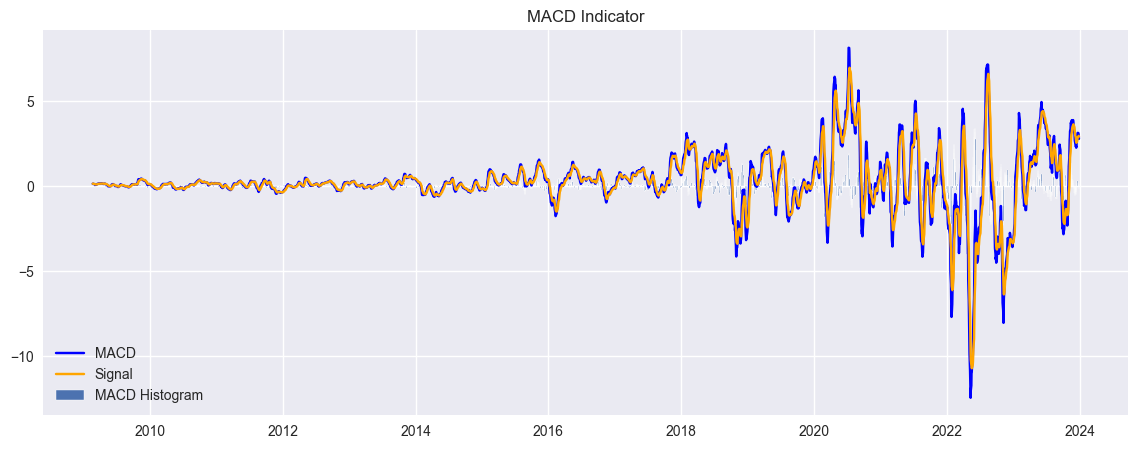

In [10]:
plt.figure(figsize=(14,5))
plt.plot(df['MACD'], label='MACD', color='blue')
plt.plot(df['MACD_signal'], label='Signal', color='orange')
plt.bar(df.index, df['MACD_hist'], label='MACD Histogram')
plt.title("MACD Indicator")
plt.legend()
plt.show()


#### Bollinger Bands

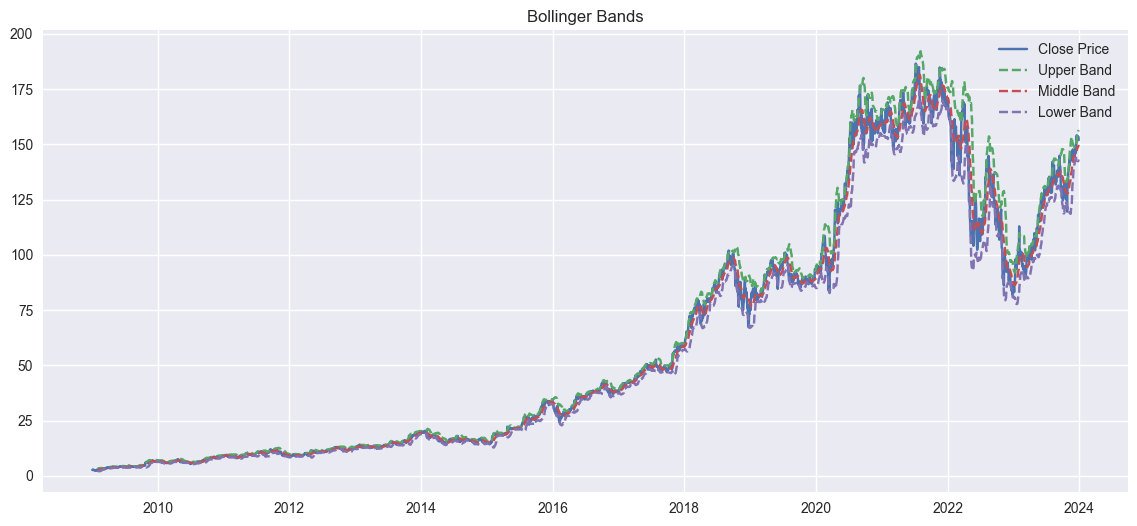

In [11]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['BB_upper'], label='Upper Band', linestyle='--')
plt.plot(df['BB_middle'], label='Middle Band', linestyle='--')
plt.plot(df['BB_lower'], label='Lower Band', linestyle='--')
plt.title("Bollinger Bands")
plt.legend()
plt.show()


### Quick look at price and volume

              count          mean           std           min           25%  \
Close        3774.0  5.940809e+01  5.491854e+01  2.422000e+00  1.219450e+01   
High         3774.0  6.011639e+01  5.561078e+01  2.505000e+00  1.230025e+01   
Low          3774.0  5.866949e+01  5.423398e+01  2.381500e+00  1.204212e+01   
Open         3774.0  5.942393e+01  5.495377e+01  2.428000e+00  1.214663e+01   
Volume       3774.0  9.185184e+07  6.057553e+07  1.762600e+07  5.586350e+07   
SMA_20       3755.0  5.931843e+01  5.470261e+01  2.615850e+00  1.217850e+01   
SMA_50       3725.0  5.919973e+01  5.441927e+01  2.966330e+00  1.223918e+01   
EMA_20       3755.0  5.932204e+01  5.467097e+01  2.615850e+00  1.221713e+01   
RSI_14       3760.0  5.456546e+01  1.170149e+01  2.116875e+01  4.582122e+01   
MACD         3741.0  2.694902e-01  1.783870e+00 -1.243150e+01 -1.368561e-01   
MACD_signal  3741.0  2.665258e-01  1.665467e+00 -1.069533e+01 -1.282355e-01   
MACD_hist    3741.0  2.964349e-03  5.663037e-01 -3.3

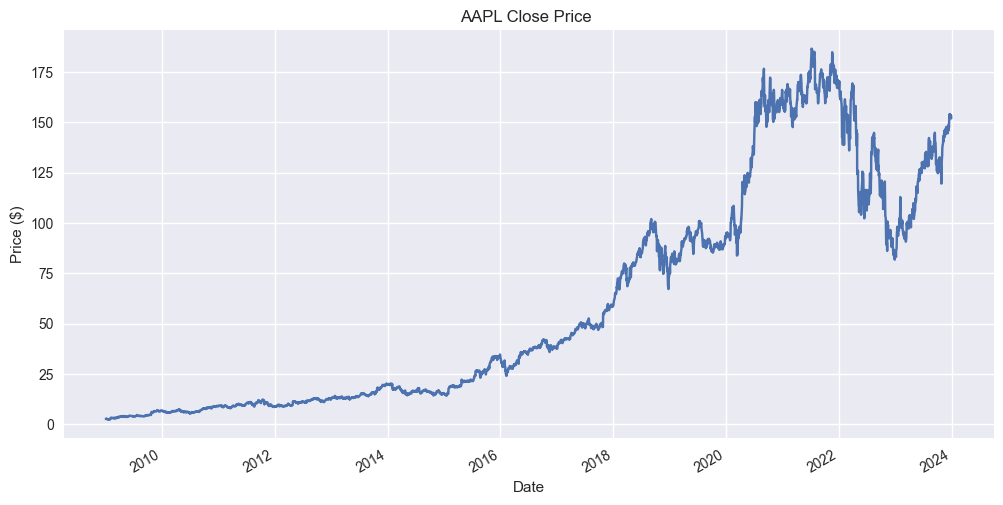

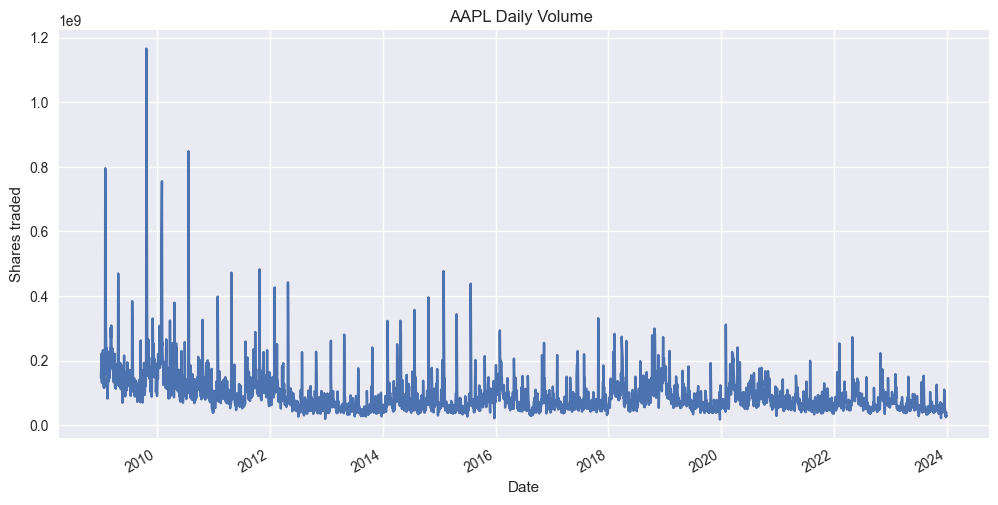

In [12]:
print(df.describe().T)

# Close price chart
df["Close"].plot(title="AAPL Close Price ")
plt.ylabel("Price ($)")
plt.show()

# Volume chart
df["Volume"].plot(title="AAPL Daily Volume ")
plt.ylabel("Shares traded")
plt.show()


### Compute technical indicators with TA-Lib

In [13]:
# Use 'Adj Close' if available, otherwise 'Close'
if "Adj Close" in df.columns:
    price = df["Adj Close"]
else:
    price = df["Close"]

# --- Moving Averages ---
df["SMA_20"] = talib.SMA(price, timeperiod=20)
df["SMA_50"] = talib.SMA(price, timeperiod=50)
df["EMA_20"] = talib.EMA(price, timeperiod=20)

# --- RSI ---
df["RSI_14"] = talib.RSI(price, timeperiod=14)

# --- MACD ---
df["MACD"], df["MACD_signal"], df["MACD_hist"] = talib.MACD(
    price, fastperiod=12, slowperiod=26, signalperiod=9
)


df.tail()


,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI_14,MACD,MACD_signal,MACD_hist,BB_upper,BB_middle,BB_lower
Date,,,,,,,,,,,,,,,
2023-12-22,153.419998,154.350006,152.710007,153.770004,29514100,148.578999,141.2430,148.860492,64.115558,3.135958,2.873052,0.262905,154.696716,148.578999,142.461283
2023-12-26,153.410004,153.979996,153.029999,153.559998,25067200,148.863000,141.7154,149.293779,64.085644,3.118650,2.922172,0.196478,155.314929,148.863000,142.411071
2023-12-27,153.339996,154.779999,153.119995,153.559998,31434700,149.178500,142.1312,149.679133,63.860893,3.063965,2.950530,0.113434,155.854273,149.178500,142.502726
2023-12-28,153.380005,154.080002,152.949997,153.720001,27057000,149.531499,142.5694,150.031597,63.938728,2.989395,2.958303,0.031092,156.311164,149.531499,142.751835
2023-12-29,151.940002,153.889999,151.029999,153.100006,39823200,149.824000,143.0456,150.213350,59.012257,2.782032,2.923049,-0.141017,156.488309,149.824000,143.159691


### Price + SMA + Bollinger Bands

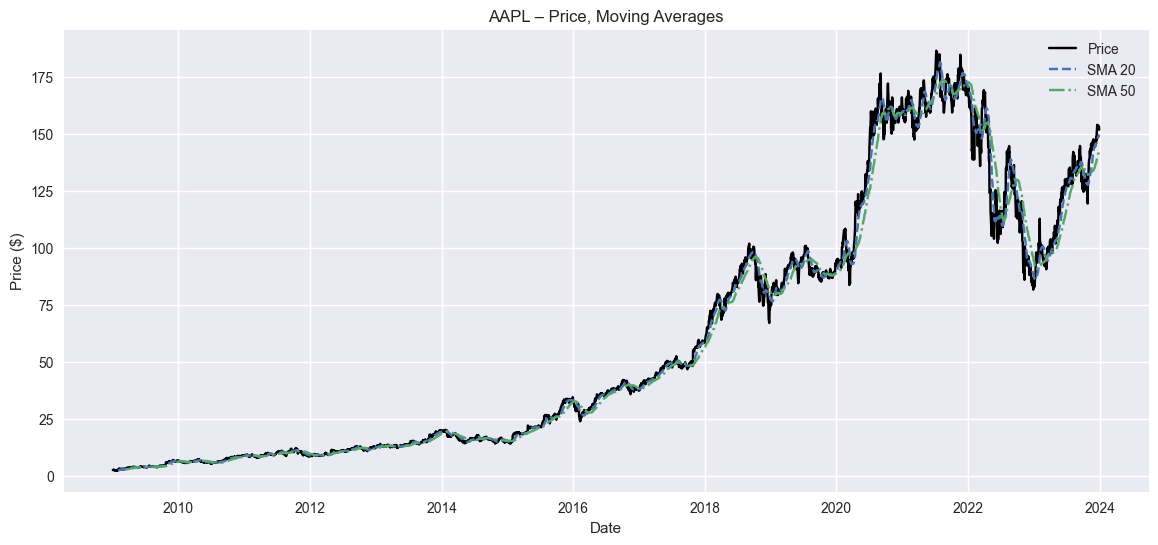

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, price, label="Price", color="black")
ax.plot(df.index, df["SMA_20"], label="SMA 20", linestyle="--")
ax.plot(df.index, df["SMA_50"], label="SMA 50", linestyle="-.")


ax.set_title("AAPL – Price, Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
plt.show()


### RSI – Overbought / Oversold

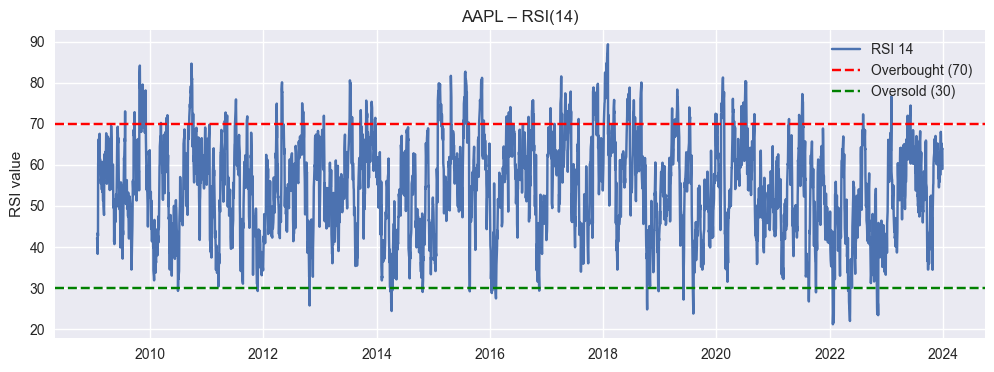

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["RSI_14"], label="RSI 14")
ax.axhline(70, color="red", linestyle="--", label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", label="Oversold (30)")

ax.set_title("AAPL – RSI(14)")
ax.set_ylabel("RSI value")
ax.legend()
plt.show()


### MACD – Trend & momentum

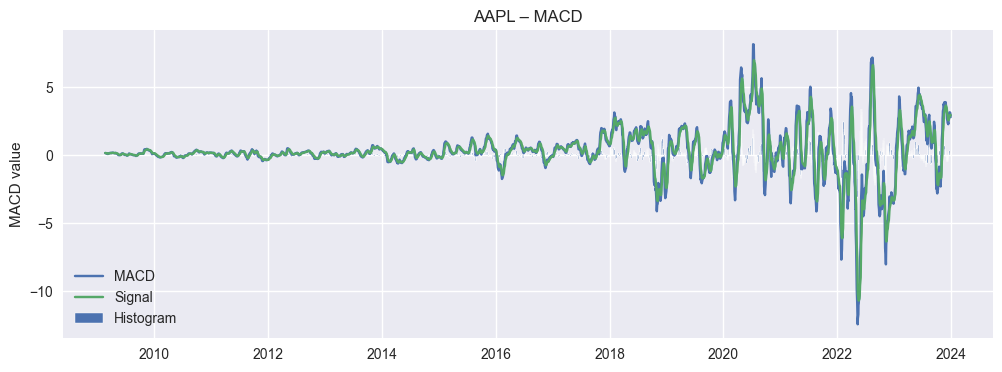

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["MACD"], label="MACD")
ax.plot(df.index, df["MACD_signal"], label="Signal")
ax.bar(df.index, df["MACD_hist"], label="Histogram")

ax.set_title("AAPL – MACD")
ax.set_ylabel("MACD value")
ax.legend()
plt.show()
